In [1]:
# Import Libraries and Load Dataset

import pandas as pd
import numpy as np

column_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment',
    'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
    'num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','class','difficulty'
]

train_df = pd.read_csv(r"C:\Users\yasha\Downloads\nsl-kdd\KDDTrain+.txt", header=None, names=column_names)
test_df  = pd.read_csv(r"C:\Users\yasha\Downloads\nsl-kdd\KDDTest+.txt", header=None, names=column_names)

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)


Train Shape: (125973, 43)
Test Shape: (22544, 43)


In [2]:
# Remove leakage column & create binary target

train_df.drop("difficulty", axis=1, inplace=True)
test_df.drop("difficulty", axis=1, inplace=True)

train_df['attack_binary'] = (train_df['class'] != 'normal').astype(int)
test_df['attack_binary']  = (test_df['class'] != 'normal').astype(int)

# Split features and labels
X_train_raw = train_df.drop(['class','attack_binary'], axis=1)
y_train = train_df['attack_binary']

X_test_raw = test_df.drop(['class','attack_binary'], axis=1)
y_test = test_df['attack_binary']


In [3]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['protocol_type', 'service', 'flag']
label_encoders = {}

X_train_enc = X_train_raw.copy()
X_test_enc  = X_test_raw.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train_enc[col])
    X_test_enc[col]  = le.transform(X_test_enc[col])
    label_encoders[col] = le

print("Categorical Columns Encoded Successfully")
print(X_train_enc[categorical_cols].head())


Categorical Columns Encoded Successfully
   protocol_type  service  flag
0              1       20     9
1              2       44     9
2              1       49     5
3              1       24     9
4              1       24     9


In [4]:
from sklearn.preprocessing import StandardScaler

numerical_cols = [col for col in X_train_raw.columns if col not in categorical_cols]

scaler = StandardScaler()

X_train_scaled = X_train_raw.copy()
X_test_scaled = X_test_raw.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_enc[numerical_cols])
X_test_scaled[numerical_cols]  = scaler.transform(X_test_enc[numerical_cols])

print("Scaled Shapes:", X_train_scaled.shape, X_test_scaled.shape)


Scaled Shapes: (125973, 41) (22544, 41)


In [5]:
from sklearn.preprocessing import StandardScaler

numerical_cols = [col for col in X_train_enc.columns if col not in categorical_cols]

scaler = StandardScaler()

X_train_scaled = X_train_enc.copy()
X_test_scaled  = X_test_enc.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_enc[numerical_cols])
X_test_scaled[numerical_cols]  = scaler.transform(X_test_enc[numerical_cols])

print("Scaled Shapes:", X_train_scaled.shape, X_test_scaled.shape)


Scaled Shapes: (125973, 41) (22544, 41)


In [ ]:
# from imblearn.over_sampling import SMOTE
# from collections import Counter

# print("Before SMOTE:", Counter(y_train))

# sm = SMOTE(random_state=42)
# X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)

# print("After SMOTE :", Counter(y_train_bal))
# print("Balanced Train Shape:", X_train_bal.shape)


Before SMOTE: Counter({0: 67343, 1: 58630})
After SMOTE : Counter({0: 67343, 1: 67343})
Balanced Train Shape: (134686, 41)


In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# import matplotlib.pyplot as plt

# rf = RandomForestClassifier(n_estimators=120, random_state=42, n_jobs=-1)
# rf.fit(X_train_bal, y_train_bal)

# importances = pd.Series(rf.feature_importances_, index=X_train_bal.columns)
# top_features = importances.sort_values(ascending=False).head(20)
# print("Top Selected Features:\n", top_features)

# # Reduced dataset
# X_train_reduced = X_train_bal[top_features.index]
# X_test_reduced = X_test_scaled[top_features.index]


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report


models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=None, min_samples_split=3, random_state=42, class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=350, max_depth=25,
        min_samples_leaf=2, random_state=42, n_jobs=-1, class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=350, learning_rate=0.1, max_depth=7,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, n_jobs=-1,scale_pos_weight = 67343 / 58630
    )
}

print("Models defined:", list(models.keys()))

X_train_for_models = X_train_scaled
y_train_for_models = y_train

X_test_for_models  = X_test_scaled
print("\n MODELS USING SMOTE + SCALING \n")

for name, model in models.items():
    print(f"Training {name}...")

    # Train model
    model.fit(X_train_for_models, y_train_for_models)

    # Predict
    preds = model.predict(X_test_for_models)

    # Print metrics
    print(f"\n{name} Accuracy: {accuracy_score(y_test, preds):.4f}")
    print("\nClassification Report:\n",
          classification_report(y_test, preds, target_names=["Normal", "Attack"]))



Models defined: ['Decision Tree', 'Random Forest', 'XGBoost']

 MODELS USING SMOTE + SCALING 

Training Decision Tree...

Decision Tree Accuracy: 0.7843

Classification Report:
               precision    recall  f1-score   support

      Normal       0.67      0.97      0.79      9711
      Attack       0.97      0.64      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.81      0.78     22544
weighted avg       0.84      0.78      0.78     22544

Training Random Forest...

Random Forest Accuracy: 0.7715

Classification Report:
               precision    recall  f1-score   support

      Normal       0.66      0.97      0.79      9711
      Attack       0.97      0.62      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.83      0.77      0.77     22544

Training XGBoost...

XGBoost Accuracy: 0.8024

Classification Report:
               

In [ ]:
# %pip install category_encoders

In [13]:
## Target Encoding

from category_encoders import MEstimateEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

categorical_cols = ['protocol_type', 'service', 'flag']

te = MEstimateEncoder(cols=categorical_cols, m=5)
te.fit(X_train_raw, y_train)

# Transformed datasets
X_train_te = te.transform(X_train_raw)
X_test_te  = te.transform(X_test_raw)

print("Target Encoding Applied for:", categorical_cols)


numerical_cols = [col for col in X_train_raw.columns if col not in categorical_cols]

scaler = StandardScaler()

X_train_te_scaled = X_train_te.copy()
X_test_te_scaled  = X_test_te.copy()

X_train_te_scaled[numerical_cols] = scaler.fit_transform(X_train_te[numerical_cols])
X_test_te_scaled[numerical_cols]  = scaler.transform(X_test_te[numerical_cols])



Target Encoding Applied for: ['protocol_type', 'service', 'flag']


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

target_encoding_models = {
    "Logistic Regression": LogisticRegression(max_iter=1500, C=2.0, n_jobs=-1, class_weight="balanced"),
    "Linear SVM": LinearSVC(C=1.0, max_iter=5000, random_state=42, class_weight="balanced"),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=250, learning_rate=0.08, max_depth=3, random_state=42
    )
}

print("\n MODELS USING TARGET ENCODING \n")
for name, model in target_encoding_models.items():
    print(f"Training {name}...")
    model.fit(X_train_te_scaled, y_train)
    preds = model.predict(X_test_te_scaled)

    print(f"\n{name} Accuracy: {accuracy_score(y_test, preds):.4f}")
    print("\nClassification Report:\n", classification_report(y_test, preds, target_names=["Normal","Attack"]))



 MODELS USING TARGET ENCODING 

Training Logistic Regression...

Logistic Regression Accuracy: 0.7511

Classification Report:
               precision    recall  f1-score   support

      Normal       0.65      0.93      0.76      9711
      Attack       0.92      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544

Training Linear SVM...

Linear SVM Accuracy: 0.7597

Classification Report:
               precision    recall  f1-score   support

      Normal       0.66      0.93      0.77      9711
      Attack       0.92      0.63      0.75     12833

    accuracy                           0.76     22544
   macro avg       0.79      0.78      0.76     22544
weighted avg       0.81      0.76      0.76     22544

Training Naive Bayes...

Naive Bayes Accuracy: 0.7767

Classification Report:
               precision    recall  f1-score   support

      N

In [17]:
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
import pandas as pd
import numpy as np


def get_metrics(model, X, y):
    preds = model.predict(X)

    # Probability / decision score for AUC
    try:
        probs = model.predict_proba(X)[:, 1]
    except:
        try:
            probs = model.decision_function(X)
        except:
            probs = None

    accuracy = accuracy_score(y, preds)
    sensitivity = recall_score(y, preds)

    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    specificity = tn / (tn + fp)

    f1 = f1_score(y, preds)
    auc = roc_auc_score(y, probs) if probs is not None else np.nan

    return accuracy, sensitivity, specificity, f1, auc



#  MODELS ON LABEL-ENCODED + SCALED DATA 

train_rows = []
test_rows = []

print("\nEVALUATING MODELS (NO SMOTE)...\n")

for name, model in models.items():

    # Train on NON-SMOTE data
    model.fit(X_train_scaled, y_train)

    # TRAIN METRICS
    tr_acc, tr_sens, tr_spec, tr_f1, tr_auc = get_metrics(
        model, X_train_scaled, y_train
    )
    train_rows.append([
        name,
        f"{tr_acc*100:.2f}%",
        f"{tr_sens*100:.2f}%",
        f"{tr_spec*100:.2f}%",
        f"{tr_f1*100:.2f}%",
        f"{tr_auc:.4f}" if not np.isnan(tr_auc) else "NA"
    ])

    # TEST METRICS
    te_acc, te_sens, te_spec, te_f1, te_auc = get_metrics(
        model, X_test_scaled, y_test
    )
    test_rows.append([
        name,
        f"{te_acc*100:.2f}%",
        f"{te_sens*100:.2f}%",
        f"{te_spec*100:.2f}%",
        f"{te_f1*100:.2f}%",
        f"{te_auc:.4f}" if not np.isnan(te_auc) else "NA"
    ])


train_df = pd.DataFrame(train_rows, columns=[
    "Model", "Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"
]).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

test_df = pd.DataFrame(test_rows, columns=[
    "Model", "Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"
]).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)


print("\n TRAIN METRICS (NO SMOTE) \n")
display(train_df)

print("\n TEST METRICS (NO SMOTE) \n")
display(test_df)



#  TARGET ENCODING MODELS 

train_rows_te = []
test_rows_te = []

print("\nEVALUATING TARGET ENCODING MODELS (NO SMOTE)...\n")

for name, model in target_encoding_models.items():

    # Train on TE-scaled data
    model.fit(X_train_te_scaled, y_train)

    # TRAIN METRICS
    tr_acc, tr_sens, tr_spec, tr_f1, tr_auc = get_metrics(
        model, X_train_te_scaled, y_train
    )
    train_rows_te.append([
        name,
        f"{tr_acc*100:.2f}%",
        f"{tr_sens*100:.2f}%",
        f"{tr_spec*100:.2f}%",
        f"{tr_f1*100:.2f}%",
        f"{tr_auc:.4f}" if not np.isnan(tr_auc) else "NA"
    ])

    # TEST METRICS
    te_acc, te_sens, te_spec, te_f1, te_auc = get_metrics(
        model, X_test_te_scaled, y_test
    )
    test_rows_te.append([
        name,
        f"{te_acc*100:.2f}%",
        f"{te_sens*100:.2f}%",
        f"{te_spec*100:.2f}%",
        f"{te_f1*100:.2f}%",
        f"{te_auc:.4f}" if not np.isnan(te_auc) else "NA"
    ])


train_df_te = pd.DataFrame(train_rows_te, columns=[
    "Model", "Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"
]).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

test_df_te = pd.DataFrame(test_rows_te, columns=[
    "Model", "Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"
]).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)


print("\n TRAIN METRICS (TARGET ENCODING, NO SMOTE) \n")
display(train_df_te)

print("\n TEST METRICS (TARGET ENCODING, NO SMOTE) \n")
display(test_df_te)



EVALUATING MODELS (NO SMOTE)...


 TRAIN METRICS (NO SMOTE) 



,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,Decision Tree,99.99%,100.00%,99.98%,99.99%,1.0000
1,XGBoost,99.99%,99.99%,100.00%,99.99%,1.0000
2,Random Forest,99.97%,99.96%,99.98%,99.97%,1.0000



 TEST METRICS (NO SMOTE) 



,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,XGBoost,80.24%,67.49%,97.09%,79.54%,0.9720
1,Decision Tree,78.43%,64.37%,97.02%,77.26%,0.8070
2,Random Forest,77.15%,62.00%,97.17%,75.54%,0.9702



EVALUATING TARGET ENCODING MODELS (NO SMOTE)...


 TRAIN METRICS (TARGET ENCODING, NO SMOTE) 



,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,Gradient Boosting,99.79%,99.67%,99.89%,99.77%,0.9999
1,Logistic Regression,97.13%,96.49%,97.68%,96.90%,0.9957
2,Linear SVM,97.11%,96.37%,97.75%,96.88%,0.9952
3,Naive Bayes,90.44%,94.13%,87.22%,90.16%,0.9587



 TEST METRICS (TARGET ENCODING, NO SMOTE) 



,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,Gradient Boosting,79.88%,66.63%,97.39%,79.03%,0.9579
1,Naive Bayes,77.67%,67.54%,91.06%,77.50%,0.8348
2,Linear SVM,75.97%,63.41%,92.58%,75.03%,0.8995
3,Logistic Regression,75.11%,61.87%,92.60%,73.89%,0.8965


TRAIN METRICS (MULTI-CLASS)


,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,Decision Tree,99.99%,99.61%,100.00%,99.80%,1.0
1,Random Forest,99.99%,99.61%,100.00%,99.80%,1.0
2,XGBoost,99.99%,99.61%,100.00%,99.80%,1.0


TEST METRICS (MULTI-CLASS)


,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,XGBoost,77.72%,51.66%,92.44%,52.24%,0.941957
1,Decision Tree,76.08%,50.35%,92.09%,51.01%,0.712184
2,Random Forest,74.82%,48.70%,91.34%,48.92%,0.871576


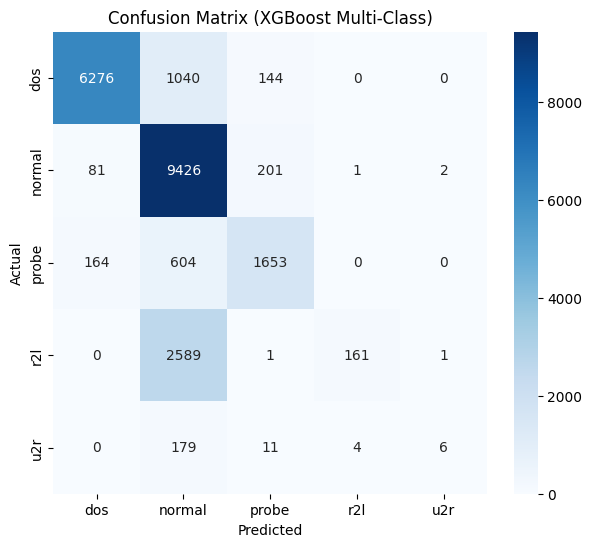

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, roc_auc_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB

# load data
column_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment',
    'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
    'num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','class','difficulty'
]

train_df = pd.read_csv(r"C:\Users\yasha\Downloads\nsl-kdd\KDDTrain+.txt", header=None, names=column_names)
test_df  = pd.read_csv(r"C:\Users\yasha\Downloads\nsl-kdd\KDDTest+.txt", header=None, names=column_names)

train_df.drop("difficulty", axis=1, inplace=True)
test_df.drop("difficulty", axis=1, inplace=True)

# map attacks to 5 classes
def map_attack(label):
    if label == "normal":
        return "normal"
    elif label in ["apache2","back","land","neptune","mailbomb","pod","processtable","smurf","teardrop","udpstorm","worm"]:
        return "dos"
    elif label in ["ipsweep","mscan","nmap","portsweep","saint","satan"]:
        return "probe"
    elif label in ["ftp_write","guess_passwd","http_tunnel","imap","multihop",
                   "named","phf","sendmail","snmpgetattack","snmpguess","spy",
                   "warezclient","warezmaster","xlock","xsnoop"]:
        return "r2l"
    else:
        return "u2r"

train_df["attack_class"] = train_df["class"].apply(map_attack)
test_df["attack_class"]  = test_df["class"].apply(map_attack)

# encode target
label_y = LabelEncoder()
y_train = label_y.fit_transform(train_df["attack_class"])
y_test  = label_y.transform(test_df["attack_class"])

# features
X_train_raw = train_df.drop(["class", "attack_class"], axis=1)
X_test_raw  = test_df.drop(["class", "attack_class"], axis=1)

categorical_cols = ["protocol_type", "service", "flag"]
numerical_cols   = [c for c in X_train_raw.columns if c not in categorical_cols]

# label encode categorical features
for col in categorical_cols:
    le = LabelEncoder()
    X_train_raw[col] = le.fit_transform(X_train_raw[col])
    X_test_raw[col]  = le.transform(X_test_raw[col])

# scale numerical features
scaler = StandardScaler()
X_train_scaled = X_train_raw.copy()
X_test_scaled  = X_test_raw.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_scaled[numerical_cols])
X_test_scaled[numerical_cols]  = scaler.transform(X_test_scaled[numerical_cols])

# models to evaluate
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=None, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=25, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=350, learning_rate=0.1, max_depth=7,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', random_state=42, n_jobs=-1
    )
}

target_encoding_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, n_jobs=-1),
    "Linear SVM": LinearSVC(max_iter=4000),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier()
}

# multi-class metrics
def multi_metrics(model, X, y):
    preds = model.predict(X)
    acc  = accuracy_score(y, preds)
    sens = recall_score(y, preds, average="macro")
    f1   = f1_score(y, preds, average="macro")

    cm = confusion_matrix(y, preds)
    spec_list = []
    for i in range(len(cm)):
        tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
        fp = cm[:,i].sum() - cm[i,i]
        spec_list.append(tn / (tn + fp + 1e-12))
    spec = np.mean(spec_list)

    try:
        y_bin = pd.get_dummies(y)
        probs = model.predict_proba(X)
        auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
    except:
        auc = np.nan

    return acc, sens, spec, f1, auc

# evaluate models (encoded+scaled)
train_rows = []
test_rows = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    tr = multi_metrics(model, X_train_scaled, y_train)
    te = multi_metrics(model, X_test_scaled, y_test)
    train_rows.append([name] + [f"{x*100:.2f}%" if i<4 else x for i,x in enumerate(tr)])
    test_rows.append([name] + [f"{x*100:.2f}%" if i<4 else x for i,x in enumerate(te)])

train_df_mc = pd.DataFrame(train_rows, columns=["Model","Accuracy","Sensitivity","Specificity","F1 Score","AUC"])
test_df_mc  = pd.DataFrame(test_rows,  columns=["Model","Accuracy","Sensitivity","Specificity","F1 Score","AUC"])

print("TRAIN METRICS (MULTI-CLASS)")
display(train_df_mc.sort_values("Accuracy", ascending=False).reset_index(drop=True))

print("TEST METRICS (MULTI-CLASS)")
display(test_df_mc.sort_values("Accuracy", ascending=False).reset_index(drop=True))

# confusion matrix for XGBoost (or choose another model)
best_model = models["XGBoost"]
preds = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_y.classes_,
            yticklabels=label_y.classes_)
plt.title("Confusion Matrix (XGBoost Multi-Class)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


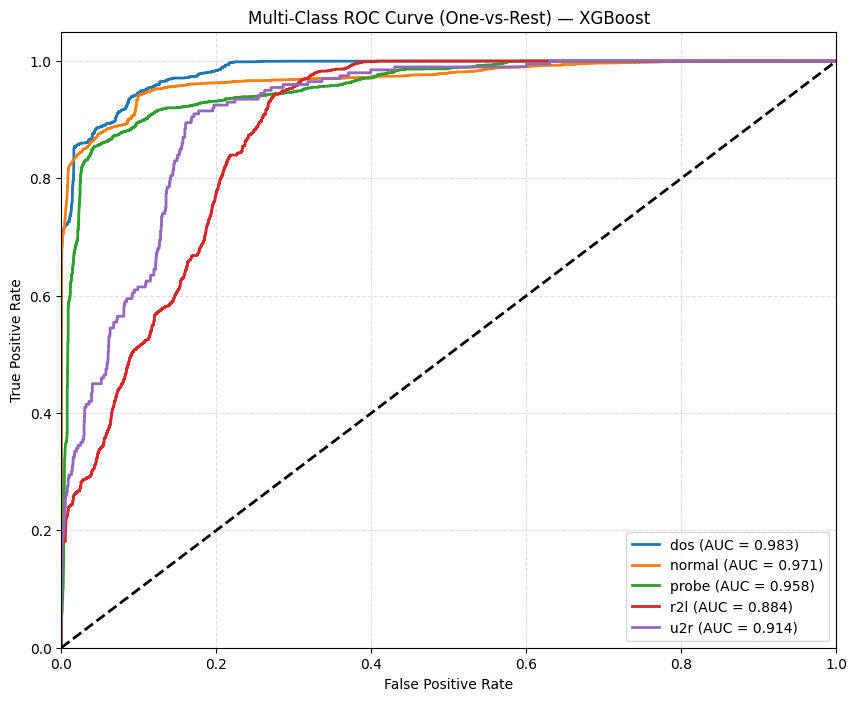

In [7]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# MULTI-CLASS ROC CURVES (One-vs-Rest)
# Class names & count
class_names = label_y.classes_
n_classes = len(class_names)

# Binarize y_test for multi-class ROC
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# Predict probabilities (required)
y_proba = best_model.predict_proba(X_test_scaled)

# Dicts to hold ROC values
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


# Plot ROC curves

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    plt.plot(
        fpr[i], tpr[i],
        lw=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (One-vs-Rest) — XGBoost")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()


In [2]:
from category_encoders import MEstimateEncoder
from sklearn.preprocessing import StandardScaler

# apply M-Estimate Target Encoding
te = MEstimateEncoder(cols=categorical_cols, m=5)
te.fit(X_train_raw, y_train)

X_train_te = te.transform(X_train_raw)
X_test_te  = te.transform(X_test_raw)

# scale numerical
X_train_te_scaled = X_train_te.copy()
X_test_te_scaled  = X_test_te.copy()

X_train_te_scaled[numerical_cols] = scaler.fit_transform(X_train_te[numerical_cols])
X_test_te_scaled[numerical_cols]  = scaler.transform(X_test_te[numerical_cols])

# target encoding models
target_encoding_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, n_jobs=-1),
    "Linear SVM": LinearSVC(max_iter=4000),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier()
}

train_rows_te = []
test_rows_te = []

for name, model in target_encoding_models.items():
    model.fit(X_train_te_scaled, y_train)

    # train metrics
    tr_acc, tr_sens, tr_spec, tr_f1, tr_auc = multi_metrics(
        model, X_train_te_scaled, y_train
    )

    train_rows_te.append([
        name,
        f"{tr_acc*100:.2f}%",
        f"{tr_sens*100:.2f}%",
        f"{tr_spec*100:.2f}%",
        f"{tr_f1*100:.2f}%",
        f"{tr_auc:.4f}" if not np.isnan(tr_auc) else "NA"
    ])

    # test metrics
    te_acc, te_sens, te_spec, te_f1, te_auc = multi_metrics(
        model, X_test_te_scaled, y_test
    )

    test_rows_te.append([
        name,
        f"{te_acc*100:.2f}%",
        f"{te_sens*100:.2f}%",
        f"{te_spec*100:.2f}%",
        f"{te_f1*100:.2f}%",
        f"{te_auc:.4f}" if not np.isnan(te_auc) else "NA"
    ])

train_df_te = pd.DataFrame(train_rows_te, columns=[
    "Model", "Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"
]).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

test_df_te = pd.DataFrame(test_rows_te, columns=[
    "Model", "Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"
]).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\nTRAIN METRICS (TARGET ENCODING MULTI-CLASS)\n")
display(train_df_te)

print("\nTEST METRICS (TARGET ENCODING MULTI-CLASS)\n")
display(test_df_te)



TRAIN METRICS (TARGET ENCODING MULTI-CLASS)



,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,Gradient Boosting,99.78%,85.68%,99.92%,89.38%,0.9151
1,Logistic Regression,97.10%,80.75%,99.03%,83.70%,0.9947
2,Linear SVM,96.49%,76.46%,98.76%,79.99%,NA
3,Naive Bayes,48.28%,65.93%,85.19%,32.95%,0.9209



TEST METRICS (TARGET ENCODING MULTI-CLASS)



,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,Gradient Boosting,77.21%,51.50%,92.24%,52.92%,0.8963
1,Logistic Regression,73.81%,49.89%,91.11%,50.12%,0.8717
2,Linear SVM,72.20%,49.02%,90.60%,49.39%,NA
3,Naive Bayes,44.21%,46.61%,84.75%,36.36%,0.7954


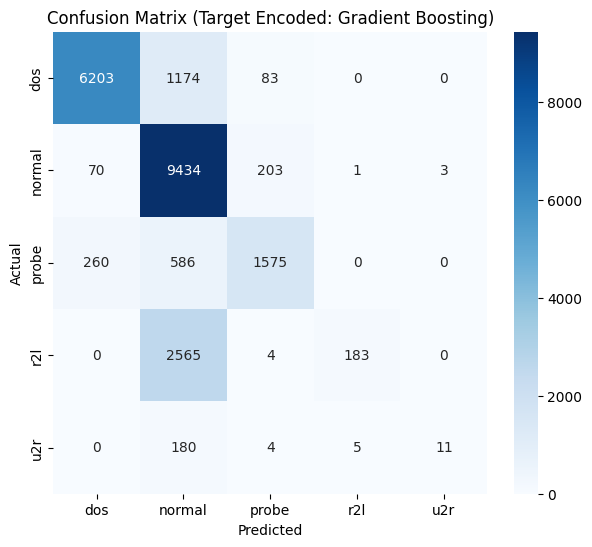

In [3]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix_te(model_name):
    model = target_encoding_models[model_name]
    preds = model.predict(X_test_te_scaled)

    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_y.classes_,
                yticklabels=label_y.classes_)
    plt.title(f"Confusion Matrix (Target Encoded: {model_name})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
plot_confusion_matrix_te("Gradient Boosting")